In [3]:
import pandas as pd
import numpy as np
import math

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [4]:
texts_df = pd.read_csv('ru_cefr_short.csv')  
features_df = pd.read_csv('ru_cefr_short_linguistic_features.csv')  


if 'text' in features_df.columns:
    features_df = features_df.drop(columns=['text'])
if 'level_number' in features_df.columns:
    features_df = features_df.drop(columns=['level_number'])

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)

print(f"Модель инициализирована")

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Модель инициализирована


In [6]:
def get_bert_embeddings(texts, batch_size=16):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            model_output = bert_model(**encoded)

        batch_embeddings = model_output.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

texts = texts_df['fragment'].fillna('').astype(str).tolist()
bert_embeddings = get_bert_embeddings(texts)
print(f"Размер BERT эмбеддингов: {bert_embeddings.shape}")

Размер BERT эмбеддингов: (7322, 768)


In [7]:
X_numerical = features_df.values

X_combined = np.hstack([X_numerical, bert_embeddings])
print(f"Объединенные фичи: {X_combined.shape}")
print(f"Числовые фичи: {X_numerical.shape[1]}, BERT эмбеддинги: {bert_embeddings.shape[1]}")

Объединенные фичи: (7322, 889)
Числовые фичи: 121, BERT эмбеддинги: 768


# Классификация

In [8]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Classifier', CatBoostClassifier(random_state=42, verbose=False)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1, n_estimators=100))
]

In [9]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

## Классификация. С1 и С2 раздельно

In [10]:
y = texts_df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [11]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [12]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [13]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,SVM,0.634812,0.634812,0.537016,0.626955,0.470990
1,7,XGBoost,0.608874,0.608874,0.547365,0.604395,0.501706
2,8,LightGBM,0.611604,0.611604,0.522974,0.603810,0.492150
3,3,CatBoost Classifier,0.603413,0.603413,0.519025,0.596592,0.505119
4,2,Random Forest,0.559727,0.559727,0.458275,0.546892,0.570648
5,0,Logistic Regression,0.530375,0.530375,0.500130,0.530232,0.603413
6,5,K-Nearest Neighbors,0.531058,0.531058,0.460857,0.525418,0.711263
7,1,Decision Tree,0.424573,0.424573,0.378635,0.425374,0.815017
8,6,Naive Bayes,0.301024,0.301024,0.292305,0.305238,1.260068


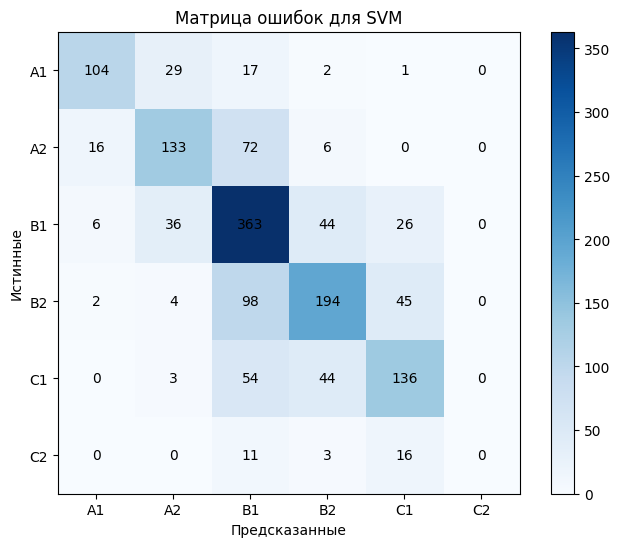

In [14]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Классификация. С1 и С2 вместе

In [15]:
y = texts_df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [16]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [17]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [18]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,SVM,0.658703,0.658703,0.663498,0.657731,0.436860
1,7,XGBoost,0.632082,0.632082,0.634421,0.631140,0.455290
2,3,CatBoost Classifier,0.628669,0.628669,0.632432,0.627628,0.470990
3,8,LightGBM,0.615700,0.615700,0.622881,0.614334,0.485324
4,2,Random Forest,0.567235,0.567235,0.565478,0.562979,0.559044
5,0,Logistic Regression,0.546758,0.546758,0.555871,0.545015,0.574061
6,5,K-Nearest Neighbors,0.539932,0.539932,0.537999,0.537665,0.688055
7,1,Decision Tree,0.415700,0.415700,0.415858,0.414874,0.821843
8,6,Naive Bayes,0.404778,0.404778,0.399501,0.375329,0.933106


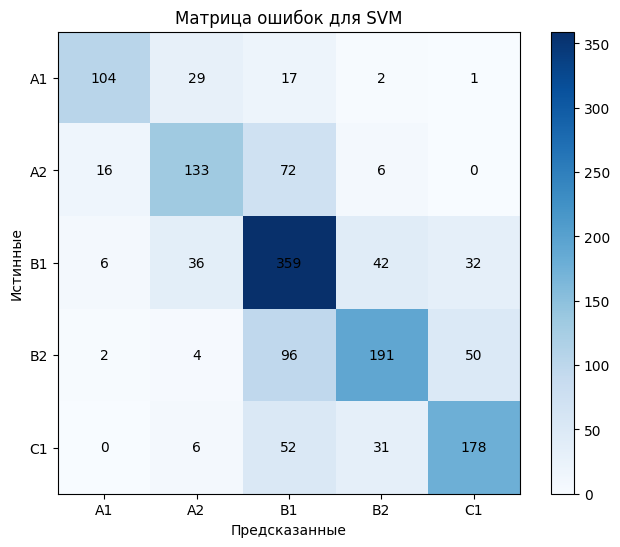

In [19]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

# Регрессия

In [20]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    # ('Random Forest', RandomForestRegressor(random_state=42, max_depth=5)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Regressor', CatBoostRegressor(random_state=42, verbose=False)),
    ('SVM', SVR()),
    ('K-Nearest Neighbors', KNeighborsRegressor()),
    # ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMRegressor(random_state=42, verbose=-1, n_estimators=100))
]

## Регрессия. С1 и С2 раздельно

In [21]:
y = texts_df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [22]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [23]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 6).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [24]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [25]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.539249,0.539249,0.457854,0.534383,0.519454
1,2,CatBoost Regressor,0.526962,0.526962,0.436879,0.520725,0.528328
2,6,LightGBM,0.526962,0.526962,0.436060,0.520422,0.536519
3,5,XGBoost,0.488055,0.488055,0.425731,0.484852,0.593857
4,0,Linear Regression,0.477133,0.477133,0.413535,0.476000,0.599317
5,4,K-Nearest Neighbors,0.480546,0.480546,0.415379,0.474711,0.645734
6,1,Decision Tree,0.421843,0.421843,0.378164,0.421792,0.806826


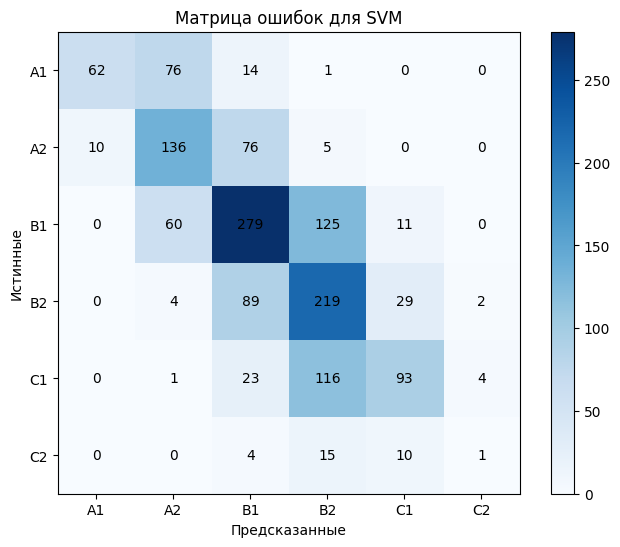

In [26]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [27]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [28]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,1,Decision Tree,0.421843,0.421843,0.378164,0.421792,0.806826
1,4,K-Nearest Neighbors,0.426621,0.426621,0.345685,0.415384,0.701024
2,3,SVM,0.399317,0.399317,0.335027,0.382932,0.702389
3,2,CatBoost Regressor,0.400000,0.400000,0.318330,0.377210,0.704437
4,5,XGBoost,0.388396,0.388396,0.341964,0.374121,0.735154
5,6,LightGBM,0.389078,0.389078,0.311972,0.369438,0.716724
6,0,Linear Regression,0.370648,0.370648,0.316708,0.366800,0.765188


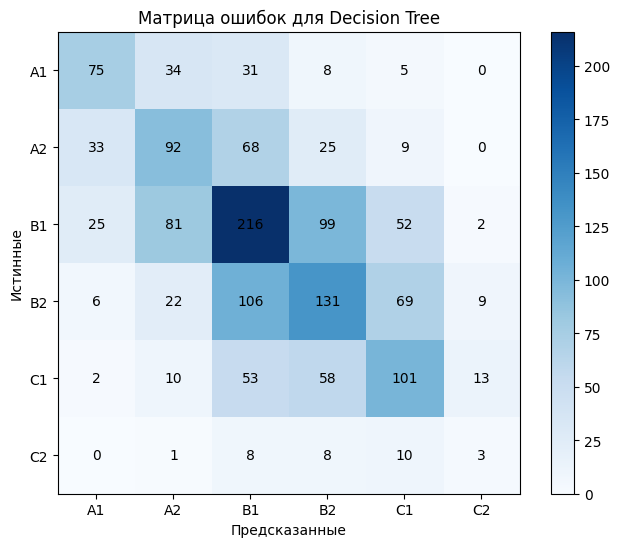

In [29]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [30]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [31]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,1,Decision Tree,0.421843,0.421843,0.378164,0.421792,0.806826
1,3,SVM,0.445051,0.445051,0.372148,0.416576,0.657338
2,0,Linear Regression,0.425256,0.425256,0.367513,0.412100,0.701706
3,6,LightGBM,0.442321,0.442321,0.350790,0.409920,0.670307
4,2,CatBoost Regressor,0.433447,0.433447,0.346177,0.402504,0.664846
5,5,XGBoost,0.421843,0.421843,0.348217,0.399545,0.705119
6,4,K-Nearest Neighbors,0.416382,0.416382,0.337506,0.391441,0.754266


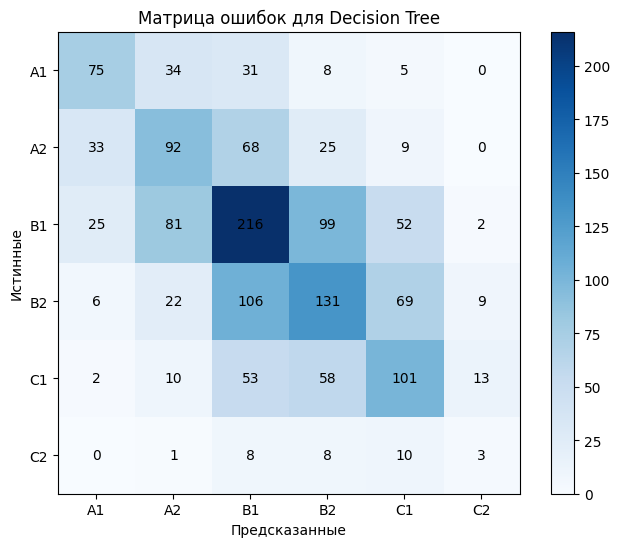

In [32]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Регрессия. С1 и С2 вместе

In [33]:
y = texts_df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [34]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [35]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 5).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [36]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [37]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,6,LightGBM,0.541980,0.541980,0.536190,0.540613,0.501024
1,3,SVM,0.537884,0.537884,0.529818,0.535638,0.505802
2,2,CatBoost Regressor,0.538567,0.538567,0.524401,0.533987,0.503072
3,5,XGBoost,0.514676,0.514676,0.516224,0.515802,0.552901
4,0,Linear Regression,0.486007,0.486007,0.482543,0.486549,0.574744
5,4,K-Nearest Neighbors,0.477816,0.477816,0.476899,0.473254,0.630034
6,1,Decision Tree,0.404778,0.404778,0.410561,0.405128,0.802730


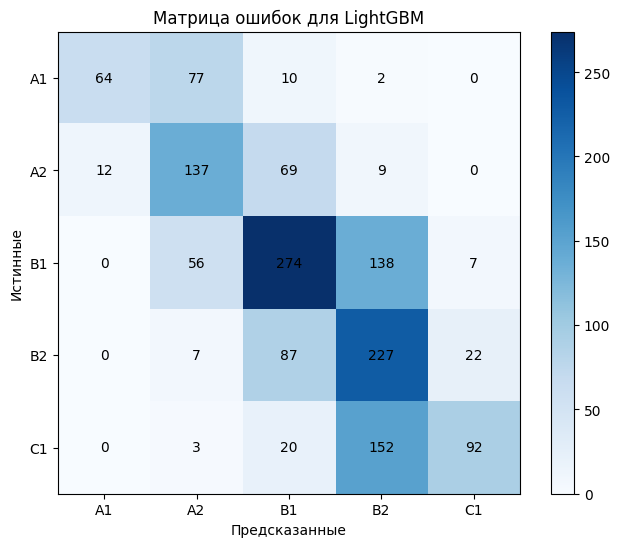

In [38]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [39]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [40]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,K-Nearest Neighbors,0.438225,0.438225,0.414547,0.430993,0.673720
1,6,LightGBM,0.433447,0.433447,0.386737,0.410333,0.653242
2,3,SVM,0.428669,0.428669,0.397426,0.409155,0.654608
3,5,XGBoost,0.421843,0.421843,0.386302,0.405612,0.683959
4,2,CatBoost Regressor,0.425939,0.425939,0.381273,0.405468,0.662799
5,1,Decision Tree,0.404778,0.404778,0.410561,0.405128,0.802730
6,0,Linear Regression,0.414334,0.414334,0.385948,0.399633,0.692833


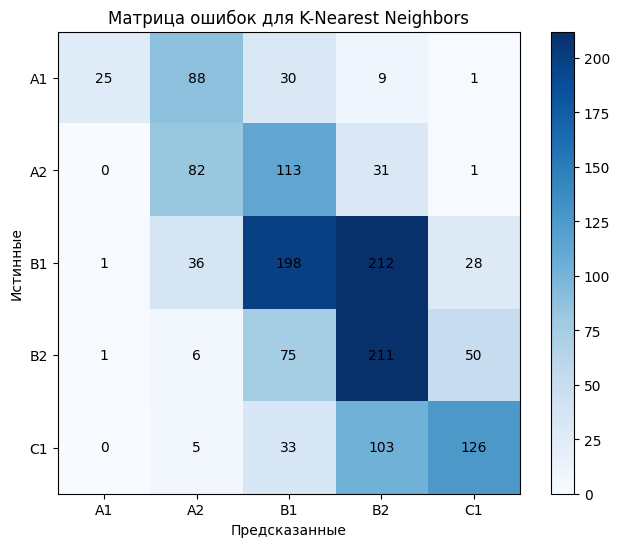

In [41]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [42]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [43]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.449829,0.449829,0.435372,0.420769,0.632765
1,0,Linear Regression,0.430717,0.430717,0.429143,0.415191,0.673038
2,1,Decision Tree,0.404778,0.404778,0.410561,0.405128,0.802730
3,5,XGBoost,0.424573,0.424573,0.412671,0.401057,0.682594
4,2,CatBoost Regressor,0.427304,0.427304,0.407188,0.394547,0.662799
5,6,LightGBM,0.427986,0.427986,0.402712,0.391030,0.655290
6,4,K-Nearest Neighbors,0.417747,0.417747,0.395439,0.389172,0.746075


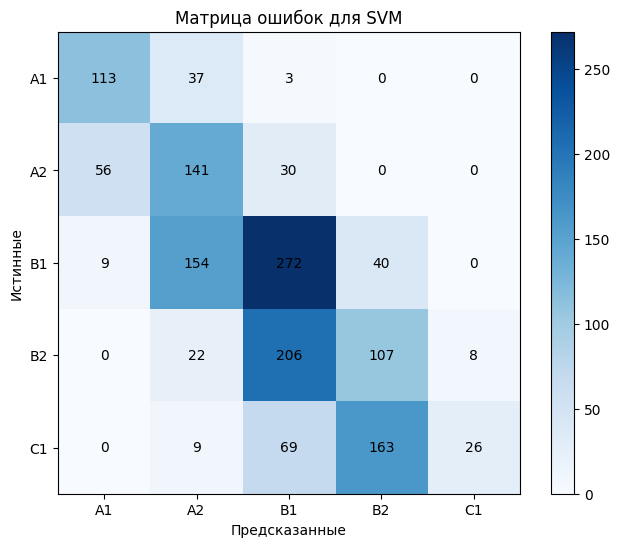

In [44]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()